In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import jax
import jax.numpy as jnp
from jax import lax, random, vmap, jit
from functools import partial

KEY = random.PRNGKey(2026)
K_MEWE = 3  # number of simulated datasets averaged for each proposal

# Consistent plot style
plt.rcParams.update({
    "figure.figsize": (7.2, 4.6),
    "figure.dpi": 110,
    "figure.facecolor": "white",
    "axes.facecolor": "#FBFCFE",
    "axes.grid": True,
    "axes.grid.which": "major",
    "axes.axisbelow": True,
    "grid.alpha": 0.28,
    "grid.color": "#D5DCE5",
    "font.size": 12,
    "axes.titlesize": 13,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "legend.frameon": False,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.edgecolor": "#B7C1CC",
    "axes.titlepad": 10,
    "savefig.bbox": "tight",
})

# Color palette used throughout
C_BLUE   = "#2166AC"
C_RED    = "#B2182B"
C_GREEN  = "#1B7837"
C_ORANGE = "#E08214"
C_PURPLE = "#6A3D9A"
C_GRAY   = "#5F6B7A"
C_LIGHT  = "#E8EEF5"


def pooled_bins(arrays, n_bins=30, expand=0.05):
    """Build common histogram bins across several 1D arrays."""
    arrays = [np.asarray(arr).ravel() for arr in arrays if len(np.asarray(arr).ravel())]
    lo = min(arr.min() for arr in arrays)
    hi = max(arr.max() for arr in arrays)
    width = hi - lo if hi > lo else 1.0
    return np.linspace(lo - expand * width, hi + expand * width, n_bins + 1)


def hist_density(values, bins):
    density, edges = np.histogram(values, bins=bins, density=True)
    centers = 0.5 * (edges[:-1] + edges[1:])
    return centers, density

# Question 1 — Reject-ABC

## Goal

We want to estimate $\theta = (\mu,\sigma^2)$ from observed data $y^\star = (y_1^\star,\dots,y_n^\star)$, where

$$
Y_i = \sum_{\ell=1}^{L}\exp(X_{i,\ell}),
\qquad
X_{i,\ell}\overset{iid}{\sim}\mathcal N(\mu,\sigma^2).
$$

As in the project statement, we first generate a synthetic observed sample from known parameters ($L=10$, $\mu_0=0$, $\sigma_0=0.3$, so $\sigma_0^2 = 0.09$). That way we know the truth and can see how well Reject-ABC manages to recover it.

## Why ABC makes sense here

The difficulty is that the density of $Y_i = \exp(X_{i,1})+\cdots+\exp(X_{i,L})$ has no closed form, so we cannot evaluate the likelihood directly. What we *can* do, though, is simulate fake data for any proposed $\theta$. That is exactly the kind of likelihood-free setting ABC is meant for:

- we cannot compute $p(y^\star\mid\theta)$,
- but we can draw $y^{\text{sim}}\sim p(\cdot\mid\theta)$,
- and we can compare $y^{\text{sim}}$ with $y^\star$ through a distance.

## The ABC posterior

The basic idea is simple: propose a parameter value $\theta^*$, simulate data under it, and keep it if the simulated sample is close enough to the observed one,

$$
d(y^{\text{sim}},\,y^\star)\leq \varepsilon.
$$

This gives samples from the ABC posterior

$$
p_\varepsilon(\theta\mid y^\star)
\;\propto\;
p(\theta)\;
\mathbb P_\theta
\!\left[
d(Y^{\text{sim}},\,y^\star)\leq \varepsilon
\right].
$$

A smaller $\varepsilon$ usually gives a better approximation to the true posterior, but it also means fewer accepted proposals. A larger $\varepsilon$ is cheaper, but rougher.

## Prior

Following the project statement, we use

$$
\mu \sim \mathcal N(0,s^2),
\qquad
\eta = \log(\sigma^2)\sim \mathcal N(0,t^2),
$$

which automatically keeps $\sigma^2 = e^\eta$ positive. One detail is worth keeping in mind from the start: the true value $\log(\sigma_0^2)=\log(0.09)\approx -2.41$ is quite far from the prior center $\eta=0$, which corresponds to $\sigma^2=1$. So if $t$ is too small, the prior will barely put any mass near the truth.

## Choice of distance

The statement mentions the MEWE distance from Bernton et al. (2017). To stay close to that idea without making the notebook too heavy, we use a simple **MEWE-style score**: for each proposed parameter, we simulate $K$ independent fake datasets and average their 1-Wasserstein distances to the observed sample.

$$
\bar W_{1,K}(\theta)
= \frac{1}{K}\sum_{k=1}^{K} W_1\bigl(y^{\mathrm{sim},(k)},\,y^\star\bigr),
\qquad K=3 \text{ in the runs below.}
$$

Because the data are one-dimensional and both samples have the same size $n$, each 1-Wasserstein term still has a simple form: sort both samples and take the mean absolute gap,

$$
W_1(y^{\text{sim}},\,y^\star)
= \frac{1}{n} \sum_{i=1}^{n} \left| y^{\text{sim}}_{(i)} - y^\star_{(i)} \right|.
$$

This keeps the full distributional comparison that makes Wasserstein attractive, while averaging over $K$ simulated datasets reduces some of the Monte Carlo noise that comes from judging a proposal with only one fake sample. We keep $K$ small so that the notebook still runs in reasonable time.

## Reject-ABC algorithm

The algorithm we use is straightforward:

$$
\boxed{
\begin{aligned}
&\textbf{Reject-ABC} \\[4pt]
&\text{Set } \texttt{accepted} = \emptyset.\\[2pt]
&\textbf{while } |\texttt{accepted}| < N \textbf{ do:}\\
&\quad 1.\;\text{Draw } \theta^* = (\mu^*,\,\sigma^{2*}) \text{ from the prior } p(\theta).\\
&\quad 2.\;\text{For } k=1,\dots,K,\text{ simulate fake data under } \theta^*:\\
&\qquad\qquad X^{*(k)}_{i,\ell} \sim \mathcal N(\mu^*,\,\sigma^{2*}),
\quad
Z^{*(k)}_i = \sum_{\ell=1}^{L}\exp(X^{*(k)}_{i,\ell}),
\quad i=1,\dots,n.\\
&\quad 3.\;\text{Compute the averaged score }
\bar d_K(\theta^*) = \frac{1}{K}\sum_{k=1}^{K} W_1(z^{*(k)},\,y^\star).\\
&\quad 4.\;\textbf{if } \bar d_K(\theta^*) \leq \varepsilon\text{:}\\
&\qquad\qquad \texttt{accepted} = \texttt{accepted}\cup\{\theta^*\}.\\
&\textbf{return } \texttt{accepted}.
\end{aligned}
}
$$

So this is still Reject-ABC, just with a slightly less noisy discrepancy than the one-shot version. The accepted draws are then used as Monte Carlo samples from the corresponding ABC approximation, from which we compute posterior means, posterior standard deviations, and 95% credible intervals.

## Implementation

To code all this up, we need a simulator for the model, the one-dimensional $W_1$ building block, and a helper that averages that distance across repeated simulations for each proposal.

In [2]:
def simulate_sum_lognormal(key, mu, sigma2, L, n):
    """
    Simulate n observations Y_i = sum_l exp(X_{i,l}), X_{i,l} ~ N(mu, sigma2).
    JAX version: key is a JAX PRNGKey.
    """
    X = mu + jnp.sqrt(sigma2) * random.normal(key, shape=(n, L))
    return jnp.sum(jnp.exp(X), axis=1)


@jit
def wasserstein1d(y_sim, y_obs_sorted):
    """
    1-Wasserstein distance between y_sim and a pre-sorted reference y_obs_sorted.
    Both must have the same length. JAX-jitted.
    """
    return jnp.mean(jnp.abs(jnp.sort(y_sim) - y_obs_sorted))


@partial(jit, static_argnums=(1, 4, 5, 6))
def _batch_proposals(key, bs, s, t, n, L, n_rep, y_obs_sorted):
    """
    Draw bs proposals from the prior, simulate n_rep datasets per proposal, and
    return their MEWE-style averaged 1-Wasserstein scores against y_obs_sorted.


    Static args: bs (batch size), n (obs size), L (log-normals per obs),
    n_rep (number of replicated datasets per proposal). This function compiles
    once per unique (bs, n, L, n_rep) tuple and is shared across all
    reject_abc / prior_predictive_scores calls.


    Returns: mus (bs,), sigma2s (bs,), scores (bs,)
    """
    k_mu, k_eta, k_sim = random.split(key, 3)
    mus     = s * random.normal(k_mu,  shape=(bs,))
    sigma2s = jnp.exp(t * random.normal(k_eta, shape=(bs,)))
    keys_rep = random.split(k_sim, bs * n_rep).reshape(bs, n_rep, 2)

    def score_one(keys_theta, mu, s2):
        def body(total, key_rep):
            y_sim = simulate_sum_lognormal(key_rep, mu, s2, L, n)
            return total + wasserstein1d(y_sim, y_obs_sorted), None

        total, _ = lax.scan(
            body,
            jnp.array(0.0, dtype=y_obs_sorted.dtype),
            keys_theta,
        )
        return total / n_rep

    scores = vmap(score_one)(keys_rep, mus, sigma2s)
    return mus, sigma2s, scores


def posterior_summary(accepted, true_values=None):
    """Summarize ABC posterior. accepted has columns [mu, sigma2]."""
    if len(accepted) == 0:
        raise ValueError("No accepted draws.")
    names = ["mu", "sigma2"]
    rows = []
    for j, name in enumerate(names):
        col = accepted[:, j]
        row = {
            "parameter": name,
            "mean"     : f"{col.mean():.4f}",
            "median"   : f"{np.median(col):.4f}",
            "std"      : f"{col.std():.4f}",
            "q2.5%"    : f"{np.quantile(col, 0.025):.4f}",
            "q97.5%"   : f"{np.quantile(col, 0.975):.4f}",
        }
        if true_values is not None:
            row["true"] = f"{true_values[j]:.4f}"
        rows.append(row)
    return pd.DataFrame(rows)


## Synthetic observed data

We now generate the observed sample from the true parameters given in the statement. Since the data are synthetic, we know the ground truth and can directly check how well Reject-ABC recovers it.

In [3]:
n = 10000
L = 10
mu_true     = 0.0
sigma_true  = 0.3
sigma2_true = sigma_true**2

KEY, key_obs = random.split(KEY)
y_obs = np.array(simulate_sum_lognormal(key_obs, mu_true, sigma2_true, L, n))

print(f"n = {n},  L = {L}")
print(f"mu_true = {mu_true},  sigma2_true = {sigma2_true}")
print(f"Observed data: mean = {y_obs.mean():.2f}, std = {y_obs.std():.2f}")


n = 10000,  L = 10
mu_true = 0.0,  sigma2_true = 0.09
Observed data: mean = 10.45, std = 1.01


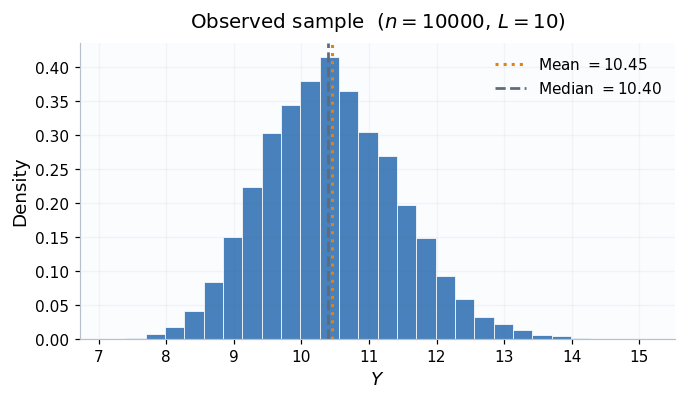

In [12]:
fig, ax = plt.subplots(figsize=(6.4, 3.8))
ax.hist(y_obs, bins=28, density=True, color=C_BLUE, edgecolor="white", alpha=0.82, linewidth=0.6)
ax.axvline(y_obs.mean(), color=C_ORANGE, lw=2, ls=":", label=fr"Mean $= {y_obs.mean():.2f}$")
ax.axvline(np.median(y_obs), color=C_GRAY, lw=1.8, ls="--", label=fr"Median $= {np.median(y_obs):.2f}$")
ax.set_xlabel(r"$Y$")
ax.set_ylabel("Density")
ax.set_title(fr"Observed sample  ($n={n}$, $L={L}$)")
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

In [6]:
def reject_abc(y_obs, L, epsilon, n_keep, s=1.0, t=1.0, n_rep=K_MEWE,
               max_proposals=500_000, seed=1234, batch_size=4096):
    """
    Reject-ABC for theta = (mu, sigma^2) using a MEWE-style score.

    Prior: mu ~ N(0, s^2),  log(sigma^2) ~ N(0, t^2).
    Each proposal is evaluated by averaging n_rep independent 1-Wasserstein
    distances between simulated datasets and the observed sample.

    Reported proposal counts/rates are based on the number of proposals
    effectively examined until the n_keep-th accepted draw is reached.
    """
    key = random.PRNGKey(seed)
    n = len(y_obs)
    y_obs_sorted = jnp.sort(jnp.array(y_obs))

    acc_mu, acc_s2, acc_score = [], [], []
    proposals = 0

    while len(acc_mu) < n_keep and proposals < max_proposals:
        remaining = n_keep - len(acc_mu)
        batch_eff = int(min(batch_size, max_proposals - proposals))

        key, subkey = random.split(key)
        mus, sigma2s, scores = _batch_proposals(
            subkey, batch_eff, float(s), float(t), n, L, int(n_rep), y_obs_sorted
        )

        mu_np = np.array(mus)
        s2_np = np.array(sigma2s)
        score_np = np.array(scores)
        accept_idx = np.flatnonzero(score_np <= epsilon)

        if accept_idx.size >= remaining:
            used_idx = accept_idx[:remaining]
            proposals += int(used_idx[-1]) + 1
        else:
            used_idx = accept_idx
            proposals += batch_eff

        for i in used_idx:
            acc_mu.append(mu_np[i])
            acc_s2.append(s2_np[i])
            acc_score.append(score_np[i])

    accepted = np.column_stack([acc_mu, acc_s2]) if acc_mu else np.empty((0, 2))
    if len(acc_mu) < n_keep:
        print(f"  Warning: only {len(acc_mu)}/{n_keep} accepted "
              f"after {proposals} proposals.")
    rate = len(acc_mu) / proposals if proposals > 0 else 0.0
    return accepted, np.array(acc_score), proposals, rate


## Calibrating $\varepsilon$

Before running ABC, we need to choose a tolerance $\varepsilon$. Under the MEWE-style rule used here, that means looking at the **prior predictive distribution of scores**: draw many $\theta$ values from the prior, simulate $K$ fake datasets under each one, average their $W_1$ distances to the observed sample, and then choose $\varepsilon$ as a low quantile of those scores.

For instance, if we take the 1% quantile, we should expect to accept about 1 proposal out of 100 drawn from the prior under the same scoring rule. That gives a rough idea of the computational cost before running the full algorithm.

In [4]:
def prior_predictive_scores(y_obs, L, s, t, n_rep=K_MEWE, n_calib=5000, seed=999):
    """
    Prior predictive MEWE-style scores — fully vectorized via JAX jit + vmap.
    All n_calib proposals are scored in one jit-compiled call.

    Returns an array of shape (n_calib,) of averaged Wasserstein scores.
    """
    key = random.PRNGKey(seed)
    n   = len(y_obs)
    y_obs_sorted = jnp.sort(jnp.array(y_obs))
    _, _, scores = _batch_proposals(
        key, n_calib, float(s), float(t), n, L, int(n_rep), y_obs_sorted
    )
    return np.array(scores)

# Default prior scales
s0, t0 = 1.0, 1.0

calib_scores = prior_predictive_scores(
    y_obs, L, s=s0, t=t0, n_rep=K_MEWE, n_calib=5000, seed=2027
)

# Candidate epsilons
quantiles = [0.20, 0.10, 0.05, 0.01, 0.005]
eps_table = {q: np.quantile(calib_scores, q) for q in quantiles}

print(f"Prior predictive calibration (s={s0}, t={t0}, K={K_MEWE}):\n")
for q, e in eps_table.items():
    print(f"  quantile {100*q:5.1f}%  =>  epsilon = {e:.4f}")


Prior predictive calibration (s=1.0, t=1.0, K=3):

  quantile  20.0%  =>  epsilon = 4.2107
  quantile  10.0%  =>  epsilon = 2.8140
  quantile   5.0%  =>  epsilon = 1.9753
  quantile   1.0%  =>  epsilon = 0.9758
  quantile   0.5%  =>  epsilon = 0.7254


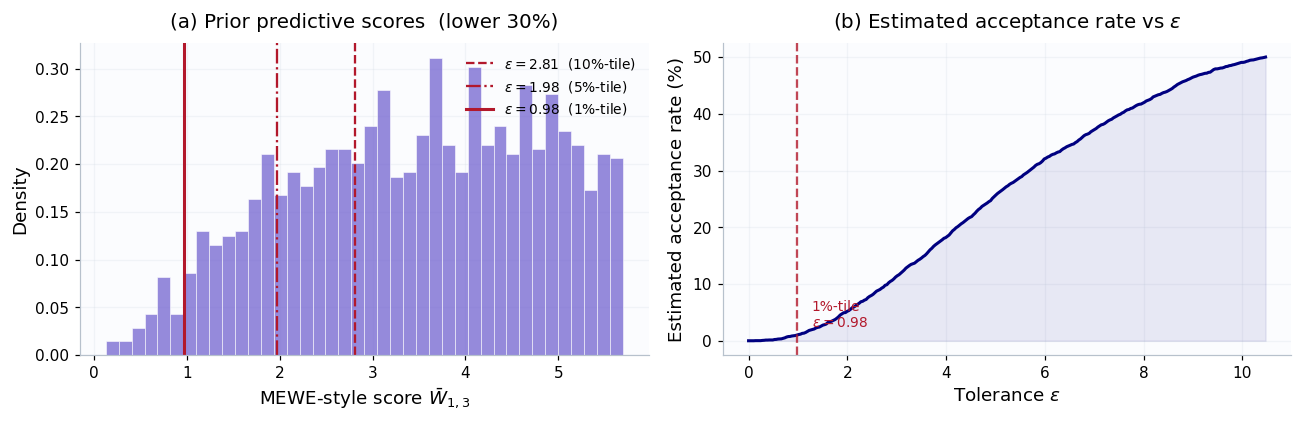

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# (a) Histogram — zoom into the low-score region where epsilon choices live
cutoff = np.quantile(calib_scores, 0.30)  # show only the left 30%
subset = calib_scores[calib_scores <= cutoff]
axes[0].hist(subset, bins=40, density=True, color="slateblue",
             edgecolor="white", alpha=0.7, linewidth=0.5)
for q, ls, lw in [(0.10, "--", 1.5), (0.05, "-.", 1.5), (0.01, "-", 2)]:
    axes[0].axvline(eps_table[q], ls=ls, lw=lw, color=C_RED,
                    label=fr"$\varepsilon={eps_table[q]:.2f}$  ({100*q:.0f}%-tile)")
axes[0].set_xlabel(fr"MEWE-style score $\bar{{W}}_{{1,{K_MEWE}}}$")
axes[0].set_ylabel("Density")
axes[0].set_title(r"(a) Prior predictive scores  (lower 30%)")
axes[0].legend(fontsize=9, loc="upper right")

# (b) Acceptance rate curve
eps_grid = np.linspace(0, np.quantile(calib_scores, 0.50), 300)
acc_curve = np.array([(calib_scores <= e).mean() * 100 for e in eps_grid])
axes[1].plot(eps_grid, acc_curve, lw=2, color="navy")
axes[1].fill_between(eps_grid, acc_curve, alpha=0.08, color="navy")
# Mark the chosen epsilon
axes[1].axvline(eps_table[0.01], color=C_RED, ls="--", lw=1.5, alpha=0.8)
axes[1].annotate(f"1%-tile\n$\\varepsilon={eps_table[0.01]:.2f}$",
                 xy=(eps_table[0.01], 1.0), fontsize=9, color=C_RED,
                 ha="left", va="bottom",
                 xytext=(eps_table[0.01] + 0.3, 2))
axes[1].set_xlabel(r"Tolerance $\varepsilon$")
axes[1].set_ylabel("Estimated acceptance rate (%)")
axes[1].set_title(r"(b) Estimated acceptance rate vs $\varepsilon$")

plt.tight_layout()
plt.show()

This is exactly what we would expect from the calibration sample. Under the prior, most parameter draws produce simulated datasets that are still far from the observed one, so the averaged Wasserstein score is usually fairly large. The left panel therefore zooms into the lower 30% of the score distribution, where the candidate $\varepsilon$ values live. Only a small fraction of prior proposals produce replicated datasets that consistently look close to $y^\star$.

The right panel is an empirical acceptance-rate curve: for each $\varepsilon$, it shows the fraction of calibration scores below that cutoff. So the 1% quantile ($\varepsilon \approx 0.98$) corresponds to an estimated acceptance rate of about 1%, or roughly 100 proposals per accepted draw. Tightening to the 0.5% quantile ($\varepsilon \approx 0.73$) lowers that to about 0.5%, or roughly 200 proposals per accepted draw.

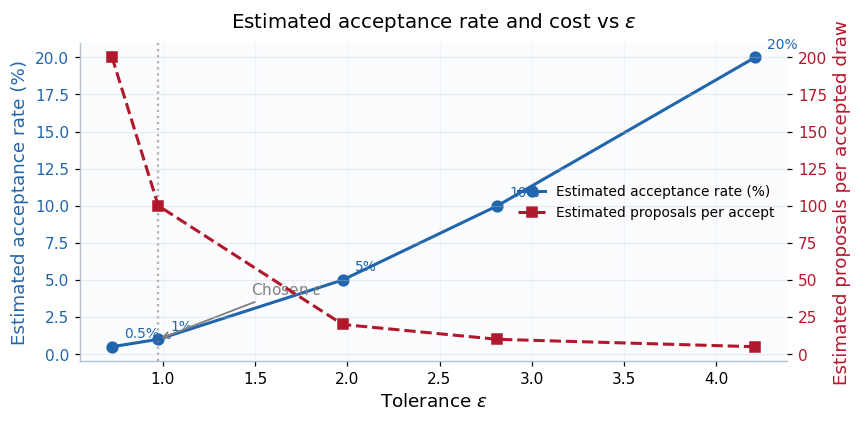

  Quantile   epsilon   Est. rate     Est. cost
----------------------------------------------
       20%     4.211      20.00%             5
       10%     2.814      10.00%            10
        5%     1.975       5.00%            20
        1%     0.976       1.00%           100
      0.5%     0.725       0.50%           200


In [9]:
# Compute empirical acceptance rate and cost for candidate epsilon values
eps_candidates = np.array([eps_table[q] for q in [0.20, 0.10, 0.05, 0.01, 0.005]])
q_labels = ["20%", "10%", "5%", "1%", "0.5%"]
acc_rates = np.array([(calib_scores <= e).mean() for e in eps_candidates])
cost_per_accept = 1.0 / acc_rates  # empirical proposals per accepted draw

fig, ax1 = plt.subplots(figsize=(8, 4))

# Left axis: acceptance rate
ln1 = ax1.plot(eps_candidates, acc_rates * 100, "o-", color=C_BLUE, lw=2,
               ms=7, label="Estimated acceptance rate (%)")
ax1.set_xlabel(r"Tolerance $\varepsilon$")
ax1.set_ylabel("Estimated acceptance rate (%)", color=C_BLUE)
ax1.tick_params(axis="y", labelcolor=C_BLUE)

# Right axis: cost per accepted draw
ax2 = ax1.twinx()
ln2 = ax2.plot(eps_candidates, cost_per_accept, "s--", color=C_RED, lw=2,
               ms=7, label="Estimated proposals per accept")
ax2.set_ylabel("Estimated proposals per accepted draw", color=C_RED)
ax2.tick_params(axis="y", labelcolor=C_RED)

# Annotate each point with the quantile label
for e, q_lab, rate, cost in zip(eps_candidates, q_labels, acc_rates, cost_per_accept):
    ax1.annotate(q_lab, (e, rate * 100), textcoords="offset points",
                 xytext=(8, 6), fontsize=9, color=C_BLUE)

# Highlight the chosen epsilon
ax1.axvline(eps_table[0.01], color="gray", ls=":", lw=1.5, alpha=0.6)
ax1.annotate(r"Chosen $\varepsilon$", xy=(eps_table[0.01], acc_rates[3]*100),
             xytext=(eps_table[0.01] + 0.5, acc_rates[3]*100 + 3),
             fontsize=10, color="gray",
             arrowprops=dict(arrowstyle="->", color="gray", lw=1.2))

# Combined legend
lns = ln1 + ln2
labs = [l.get_label() for l in lns]
ax1.legend(lns, labs, fontsize=9, loc="center right")

ax1.set_title(r"Estimated acceptance rate and cost vs $\varepsilon$")
plt.tight_layout()
plt.show()

# Print table
print(f"{'Quantile':>10s}  {'epsilon':>8s}  {'Est. rate':>10s}  {'Est. cost':>12s}")
print("-" * 46)
for q_lab, e, rate, cost in zip(q_labels, eps_candidates, acc_rates, cost_per_accept):
    print(f"{q_lab:>10s}  {e:8.3f}  {100*rate:9.2f}%  {cost:12.0f}")

This figure does not directly plot approximation error. It plots the estimated acceptance rate and the estimated proposals per accepted draw as $\varepsilon$ varies. In ABC, smaller $\varepsilon$ typically gives a stricter and usually more accurate approximation, so this operational plot is best read as evidence for the approximation-computation tradeoff rather than as a direct error curve.

Looking at the numbers, moving from the 10% to the 1% quantile costs about ten times more proposals per accepted draw, but it also filters much more aggressively. Going from 1% to 0.5% roughly doubles the cost again for a smaller extra gain.

For that reason, we use the **1% quantile** (here $\varepsilon \approx 0.98$) in the main run. It is strict enough to remove many loose matches, while still being computationally manageable on a laptop.

The approximation side of this tradeoff is assessed next by comparing posterior estimates across values of $\varepsilon$.

## Main Reject-ABC run

With $\varepsilon$ fixed at the 1% prior-predictive quantile, we can now run Reject-ABC and keep 500 accepted draws. Each proposal is judged with the averaged score based on $K=3$ simulated datasets.

In [10]:
eps_main = eps_table[0.01]

accepted, scores_acc, n_prop, acc_rate = reject_abc(
    y_obs, L, epsilon=eps_main, n_keep=500,
    s=s0, t=t0, n_rep=K_MEWE, max_proposals=500_000, seed=2028
)

print(f"epsilon       = {eps_main:.4f}")
print(f"accepted      = {len(accepted)}")
print(f"proposals     = {n_prop}")
print(f"accept. rate  = {acc_rate:.4f}  ({100*acc_rate:.2f}%)")
print(f"correlation   = {np.corrcoef(accepted[:,0], accepted[:,1])[0,1]:.3f}")
print()
posterior_summary(accepted, true_values=[mu_true, sigma2_true])

epsilon       = 0.9758
accepted      = 500
proposals     = 49535
accept. rate  = 0.0101  (1.01%)
correlation   = -0.669



,parameter,mean,median,std,q2.5%,q97.5%,true
0,mu,-0.0750,-0.0834,0.0642,-0.1729,0.0586,0.0000
1,sigma2,0.2291,0.2339,0.0827,0.0675,0.3667,0.0900


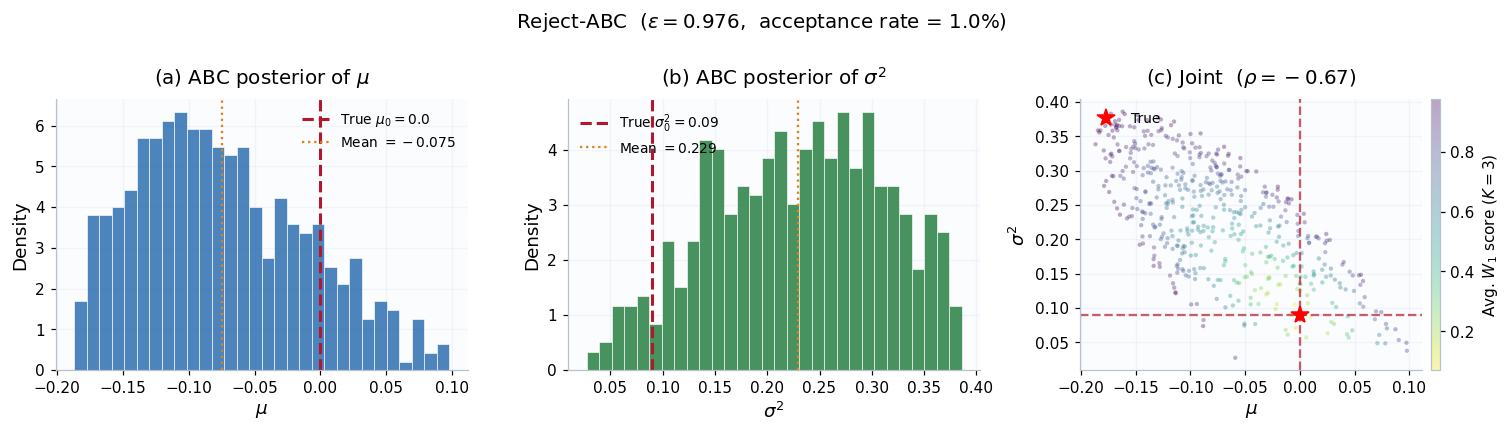

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# (a) mu
axes[0].hist(accepted[:, 0], bins=30, density=True, color=C_BLUE,
             edgecolor="white", alpha=0.8, linewidth=0.5)
axes[0].axvline(mu_true, color=C_RED, lw=2, ls="--", label=fr"True $\mu_0 = {mu_true}$")
axes[0].axvline(accepted[:, 0].mean(), color=C_ORANGE, lw=1.5, ls=":",
                label=fr"Mean $= {accepted[:, 0].mean():.3f}$")
axes[0].set_xlabel(r"$\mu$")
axes[0].set_ylabel("Density")
axes[0].set_title(r"(a) ABC posterior of $\mu$")
axes[0].legend(fontsize=9)

# (b) sigma^2
axes[1].hist(accepted[:, 1], bins=30, density=True, color=C_GREEN,
             edgecolor="white", alpha=0.8, linewidth=0.5)
axes[1].axvline(sigma2_true, color=C_RED, lw=2, ls="--",
                label=fr"True $\sigma_0^2 = {sigma2_true}$")
axes[1].axvline(accepted[:, 1].mean(), color=C_ORANGE, lw=1.5, ls=":",
                label=fr"Mean $= {accepted[:, 1].mean():.3f}$")
axes[1].set_xlabel(r"$\sigma^2$")
axes[1].set_ylabel("Density")
axes[1].set_title(r"(b) ABC posterior of $\sigma^2$")
axes[1].legend(fontsize=9)

# (c) joint
sc = axes[2].scatter(accepted[:, 0], accepted[:, 1], s=8, alpha=0.35,
                     c=scores_acc, cmap="viridis_r", edgecolors="none")
axes[2].axvline(mu_true, color=C_RED, ls="--", lw=1.5, alpha=0.7)
axes[2].axhline(sigma2_true, color=C_RED, ls="--", lw=1.5, alpha=0.7)
axes[2].plot(mu_true, sigma2_true, "r*", ms=12, zorder=5, label="True")
axes[2].set_xlabel(r"$\mu$")
axes[2].set_ylabel(r"$\sigma^2$")
axes[2].set_title(fr"(c) Joint  ($\rho = {np.corrcoef(accepted[:,0], accepted[:,1])[0,1]:.2f}$)")
axes[2].legend(fontsize=9, loc="upper left")
cb = plt.colorbar(sc, ax=axes[2], pad=0.02, aspect=30)
cb.set_label(fr"Avg. $W_1$ score ($K={K_MEWE}$)", fontsize=10)

plt.suptitle(fr"Reject-ABC  ($\varepsilon = {eps_main:.3f}$,  acceptance rate = {100*acc_rate:.1f}%)",
             fontsize=13)
plt.tight_layout()
plt.show()

**Observations from the main run** ($\varepsilon$ around the 1% prior-predictive quantile, acceptance rate around 1%):

With this choice of $\varepsilon$, the picture is mixed in a fairly sensible way. The posterior for $\mu$ is reasonably close to the truth: it is still a bit shifted to the left, but the 95% credible interval covers $\mu_0 = 0$. The joint posterior also makes the tradeoff between $\mu$ and $\sigma^2$ easy to see. Larger values of $\sigma^2$ tend to come with smaller values of $\mu$, which makes sense because both parameters affect the overall scale of $Y_i = \sum \exp(X_{i,\ell})$.

The harder parameter is $\sigma^2$. Its posterior is still centered well above the true value $0.09$. For Question 1, I would not read that as a problem with the implementation. It is better seen as the main limitation of Reject-ABC under the default setup. We are still using a positive tolerance $\varepsilon$, so some ABC approximation bias is unavoidable, and on top of that the prior on $\log\sigma^2$ is centered at $\sigma^2 = 1$, which pulls upward as well.

So the takeaway from the main run is straightforward: Reject-ABC is clearly learning from the data, but with this prior and this tolerance it does not recover $\sigma^2$ especially cleanly.

## Effect of $\varepsilon$

Next, we vary $\varepsilon$ and see how the posterior changes.

The basic expectation is simple: smaller $\varepsilon$ should pull the ABC posterior closer to the truth and make it tighter, but we pay for that with a lower acceptance rate.

In [13]:
eps_levels = [
    (0.20, "q=20%"),
    (0.10, "q=10%"),
    (0.01, "q=1%"),
    (0.005, "q=0.5%"),
]

eps_results = []
for j, (q, label) in enumerate(eps_levels):
    eps_val = eps_table[q]
    acc_j, _, nprop_j, rate_j = reject_abc(
        y_obs, L, epsilon=float(eps_val), n_keep=400,
        s=s0, t=t0, max_proposals=500_000, seed=3000 + j
    )
    eps_results.append({
        "quantile": label, "epsilon": eps_val,
        "n_accepted": len(acc_j), "n_proposals": nprop_j,
        "acc_rate": rate_j, "samples": acc_j,
    })

# Summary table
summary_rows = []
for r in eps_results:
    row = {
        "quantile": r["quantile"],
        "epsilon": f'{r["epsilon"]:.4f}',
        "accepted": r["n_accepted"],
        "proposals": r["n_proposals"],
        "acc. rate (%)": f'{100*r["acc_rate"]:.2f}',
    }
    if len(r["samples"]):
        row["E[mu]"] = f'{r["samples"][:, 0].mean():.4f}'
        row["E[sigma2]"] = f'{r["samples"][:, 1].mean():.4f}'
    else:
        row["E[mu]"] = chr(8212)
        row["E[sigma2]"] = chr(8212)
    summary_rows.append(row)

print(pd.DataFrame(summary_rows).to_string(index=False))

quantile epsilon  accepted  proposals acc. rate (%)   E[mu] E[sigma2]
   q=20%  4.2107       400       2137         18.72 -0.3684    0.6798
   q=10%  2.8140       400       4043          9.89 -0.2447    0.5215
    q=1%  0.9758       400      40681          0.98 -0.0722    0.2183
  q=0.5%  0.7254       400      70178          0.57 -0.0470    0.1805


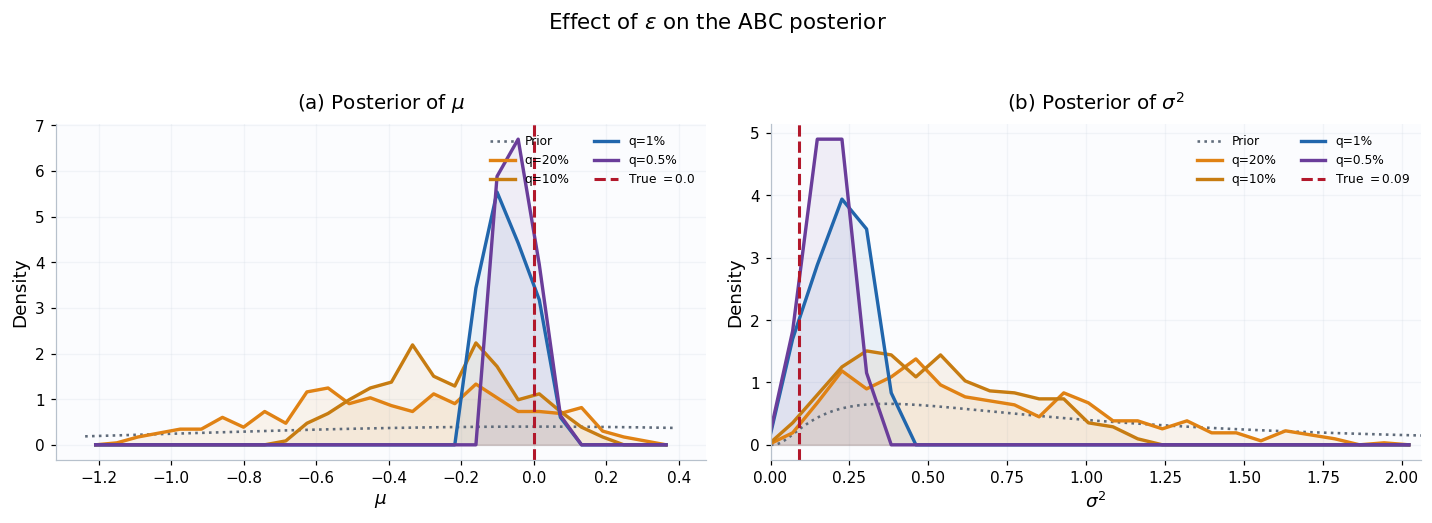

In [14]:
colors = [C_ORANGE, "#C77C11", C_BLUE, C_PURPLE]

fig, axes = plt.subplots(1, 2, figsize=(13.2, 4.6), sharey=False)

mu_arrays = [r["samples"][:, 0] for r in eps_results if len(r["samples"])]
s2_arrays = [r["samples"][:, 1] for r in eps_results if len(r["samples"])]
mu_bins = pooled_bins(mu_arrays, n_bins=28, expand=0.08)
s2_bins = pooled_bins(s2_arrays, n_bins=28, expand=0.08)

# --- (a) Posterior of mu ---
x_mu = np.linspace(mu_bins[0], mu_bins[-1], 400)
prior_mu = (1 / (np.sqrt(2*np.pi) * s0)) * np.exp(-0.5 * (x_mu / s0)**2)
axes[0].plot(x_mu, prior_mu, ":", color=C_GRAY, lw=1.7, label="Prior")
for r, c in zip(eps_results, colors):
    if len(r["samples"]):
        centers, density = hist_density(r["samples"][:, 0], mu_bins)
        axes[0].plot(centers, density, color=c, lw=2.2, label=r["quantile"])
        axes[0].fill_between(centers, density, color=c, alpha=0.08)
axes[0].axvline(mu_true, color=C_RED, lw=2, ls="--", label=fr"True $= {mu_true}$")
axes[0].set_xlabel(r"$\mu$")
axes[0].set_ylabel("Density")
axes[0].set_title(r"(a) Posterior of $\mu$")
axes[0].legend(fontsize=8, ncol=2, loc="upper right")

# --- (b) Posterior of sigma^2 ---
x_s2 = np.linspace(max(1e-3, s2_bins[0]), s2_bins[-1], 500)
eta_pdf = (1 / (np.sqrt(2*np.pi) * t0)) * np.exp(-0.5 * (np.log(x_s2) / t0)**2)
prior_s2 = eta_pdf / x_s2
axes[1].plot(x_s2, prior_s2, ":", color=C_GRAY, lw=1.7, label="Prior")
for r, c in zip(eps_results, colors):
    if len(r["samples"]):
        centers, density = hist_density(r["samples"][:, 1], s2_bins)
        axes[1].plot(centers, density, color=c, lw=2.2, label=r["quantile"])
        axes[1].fill_between(centers, density, color=c, alpha=0.08)
axes[1].axvline(sigma2_true, color=C_RED, lw=2, ls="--", label=fr"True $= {sigma2_true}$")
axes[1].set_xlim(max(0, s2_bins[0]), s2_bins[-1])
axes[1].set_xlabel(r"$\sigma^2$")
axes[1].set_ylabel("Density")
axes[1].set_title(r"(b) Posterior of $\sigma^2$")
axes[1].legend(fontsize=8, ncol=2, loc="upper right")

plt.suptitle(r"Effect of $\varepsilon$ on the ABC posterior", fontsize=14, y=1.03)
plt.tight_layout()
plt.show()

**Observations on the effect of $\varepsilon$:**

The pattern is exactly the one we would hope to see: as $\varepsilon$ gets smaller, the posterior moves closer to the truth and becomes more concentrated.

For Question 1, the main point here is not to find a magic tolerance, but to make the tradeoff visible. With a loose tolerance, the ABC posterior is still heavily shaped by the prior and $\sigma^2$ is badly overestimated. Tightening $\varepsilon$ reduces that bias, but it also makes acceptance much rarer, so the computation becomes noticeably more expensive.

It is also not surprising that some bias remains even at the smallest tolerance we tried. A positive $\varepsilon$ always leaves some ABC approximation error, and in this notebook that effect is reinforced by the prior on $\log\sigma^2$, which is centered too far above the truth.

That is why the 1% quantile is best viewed as a practical compromise. It gives a clear improvement over looser choices without making the run too expensive.

## Sensitivity to the prior scales $s$ and $t$

The statement also asks us to discuss how $s$ and $t$ affect the results. We keep $\varepsilon$ fixed at the 1% quantile and vary one prior scale at a time.

The rough intuition is simple. A wider prior can waste proposals in extreme regions, which lowers the acceptance rate, while a prior that is too tight may fail to cover the true parameter region at all. Here we expect $t$ to matter more than $s$, because the prior on $\log\sigma^2$ is centered at $\sigma^2 = 1$, which is far from the true value $0.09$.

In [15]:
# --- Vary s (prior width on mu), keep t fixed ---
s_grid = [0.3, 1.0, 3.0]
s_runs = []
for j, s_try in enumerate(s_grid):
    acc_s, _, _, rate_s = reject_abc(
        y_obs, L, epsilon=eps_main, n_keep=300,
        s=s_try, t=t0, max_proposals=500_000, seed=4000 + j
    )
    s_runs.append((s_try, acc_s, rate_s))

# --- Vary t (prior width on log sigma^2), keep s fixed ---
t_grid = [0.3, 1.0, 3.0]
t_runs = []
for j, t_try in enumerate(t_grid):
    acc_t, _, _, rate_t = reject_abc(
        y_obs, L, epsilon=eps_main, n_keep=300,
        s=s0, t=t_try, max_proposals=500_000, seed=5000 + j
    )
    t_runs.append((t_try, acc_t, rate_t))

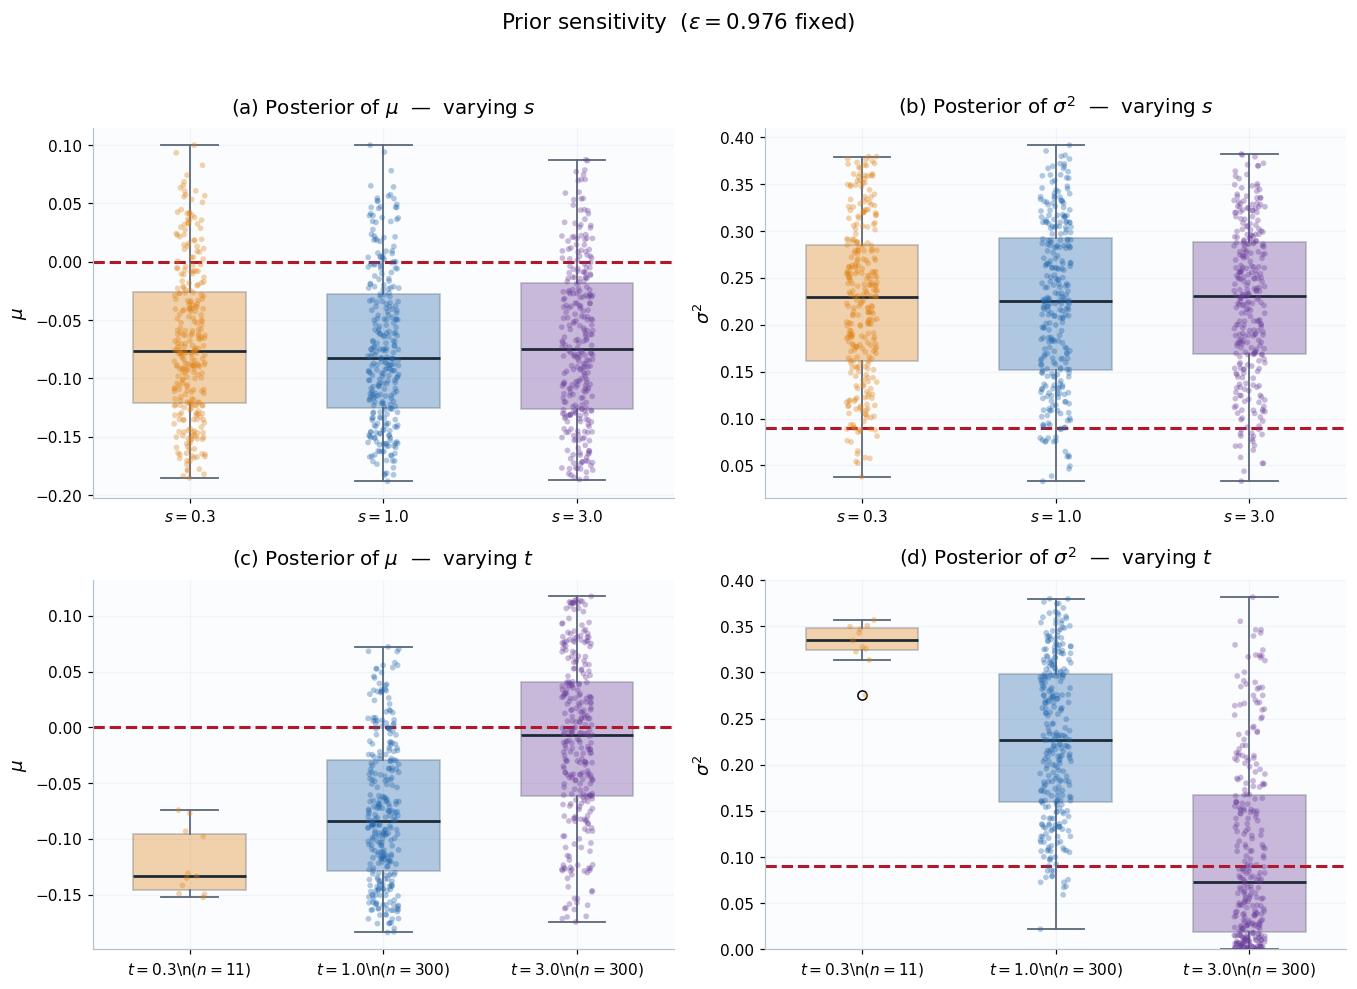

Acceptance rates:

  Varying s (t = 1.0 fixed):
    s = 0.3  =>  3.34%
    s = 1.0  =>  1.02%
    s = 3.0  =>  0.35%

  Varying t (s = 1.0 fixed):
    t = 0.3  =>  0.00%  (n=11)
    t = 1.0  =>  1.10%  (n=300)
    t = 3.0  =>  2.67%  (n=300)


In [16]:
fig, axes = plt.subplots(2, 2, figsize=(12.5, 8.8))

series = [
    (axes[0, 0], [acc[:, 0] for _, acc, _ in s_runs], [fr"$s={s}$" for s, _, _ in s_runs], mu_true, r"(a) Posterior of $\mu$  —  varying $s$", r"$\mu$"),
    (axes[0, 1], [acc[:, 1] for _, acc, _ in s_runs], [fr"$s={s}$" for s, _, _ in s_runs], sigma2_true, r"(b) Posterior of $\sigma^2$  —  varying $s$", r"$\sigma^2$"),
    (axes[1, 0], [acc[:, 0] for _, acc, _ in t_runs], [fr"$t={t}$\n$(n={len(acc)})$" for t, acc, _ in t_runs], mu_true, r"(c) Posterior of $\mu$  —  varying $t$", r"$\mu$"),
    (axes[1, 1], [acc[:, 1] for _, acc, _ in t_runs], [fr"$t={t}$\n$(n={len(acc)})$" for t, acc, _ in t_runs], sigma2_true, r"(d) Posterior of $\sigma^2$  —  varying $t$", r"$\sigma^2$"),
]

palette = [C_ORANGE, C_BLUE, C_PURPLE]
rng_box = np.random.default_rng(2026)

for ax, data, labels, true_val, title, ylabel in series:
    bp = ax.boxplot(
        data,
        tick_labels=labels,
        patch_artist=True,
        widths=0.58,
        medianprops=dict(color="#1C2833", lw=1.8),
        whiskerprops=dict(color=C_GRAY, lw=1.2),
        capprops=dict(color=C_GRAY, lw=1.2),
        boxprops=dict(linewidth=1.2, color=C_GRAY),
    )
    for patch, color in zip(bp["boxes"], palette):
        patch.set_facecolor(color)
        patch.set_alpha(0.35)

    for xpos, values, color in zip(range(1, len(data) + 1), data, palette):
        if len(values):
            jitter = rng_box.uniform(-0.08, 0.08, size=len(values))
            ax.scatter(
                np.full(len(values), xpos) + jitter,
                values,
                s=14,
                color=color,
                alpha=0.35,
                edgecolors="none",
                zorder=3,
            )

    ax.axhline(true_val, color=C_RED, ls="--", lw=2)
    ax.set_title(title)
    ax.set_ylabel(ylabel)

axes[1, 1].set_ylim(bottom=0)
plt.suptitle(fr"Prior sensitivity  ($\varepsilon = {eps_main:.3f}$ fixed)", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# Acceptance rates table
print("Acceptance rates:\n")
print(f"  Varying s (t = {t0:.1f} fixed):")
for s_try, _, rate in s_runs:
    print(f"    s = {s_try:.1f}  =>  {100*rate:.2f}%")
print(f"\n  Varying t (s = {s0:.1f} fixed):")
for t_try, acc_t, rate in t_runs:
    print(f"    t = {t_try:.1f}  =>  {100*rate:.2f}%  (n={len(acc_t)})")

**Varying $s$ (width of the prior on $\mu$, with $t = 1$ fixed):**

Changing $s$ barely changes the posterior itself. What really moves is the efficiency: a wider prior on $\mu$ sends more proposals to extreme values, so the acceptance rate drops, but the posterior summaries remain very similar. That is consistent with the fact that the prior is already centered at the true $\mu_0 = 0$.

**Varying $t$ (width of the prior on $\log\sigma^2$, with $s = 1$ fixed):**

This is where the prior really matters. When $t = 0.3$, the prior is so tightly concentrated around $\sigma^2 = 1$ that almost none of its mass reaches the true region near $0.09$. Reject-ABC then accepts almost nothing, and the few accepted draws are still badly biased. Since only 11 draws were accepted for $t = 0.3$, this case should be interpreted as a near-failure rather than as a stable posterior comparison. When $t = 3.0$, the picture improves a lot: the posterior moves much closer to the truth and the acceptance rate goes up, simply because the prior finally puts enough weight where the data want it.

So the main lesson here is clear. In this problem, the prior on $\log\sigma^2$ matters much more than the prior on $\mu$. Since $\varepsilon$ is kept fixed, I would read this as a sensitivity analysis rather than a perfectly controlled comparison across priors, but it still makes the main point very well.

## Numerical error assessment

To separate Monte Carlo noise from systematic ABC error, we rerun Reject-ABC 20 times with different random seeds while keeping the same observed data and the same $\varepsilon$.

If the results barely move from run to run, then the main issue is not randomness in the simulation but bias from the approximation itself.

In [17]:
n_repeats = 20
repeat_quantiles = [0.10, 0.01]

mu_box, s2_box, labels_box = [], [], []

for q in repeat_quantiles:
    eps_val = eps_table[q]
    mu_reps, s2_reps = [], []
    for r in range(n_repeats):
        acc_r, _, _, _ = reject_abc(
            y_obs, L, epsilon=float(eps_val), n_keep=200,
            s=s0, t=t0, max_proposals=300_000,
            seed=7000 + 100 * int(100 * q) + r
        )
        if len(acc_r) > 0:
            mu_reps.append(acc_r[:, 0].mean())
            s2_reps.append(acc_r[:, 1].mean())
    mu_box.append(mu_reps)
    s2_box.append(s2_reps)
    labels_box.append(f"q={100*q:.0f}%\n(" + chr(949) + f"={eps_val:.3f})")

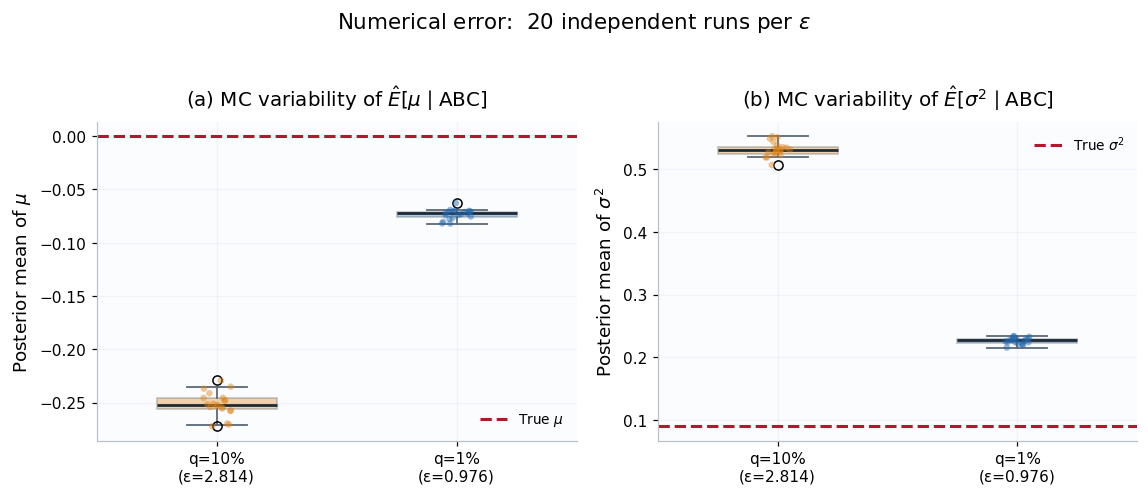

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(10.6, 4.4))

box_colors = [C_ORANGE, C_BLUE]
rng_mc = np.random.default_rng(2031)

for ax, data, ylabel, param, true_val in [
    (axes[0], mu_box, r"Posterior mean of $\mu$", r"$\mu$", mu_true),
    (axes[1], s2_box, r"Posterior mean of $\sigma^2$", r"$\sigma^2$", sigma2_true),
]:
    bp = ax.boxplot(
        data,
        tick_labels=labels_box,
        patch_artist=True,
        widths=0.5,
        medianprops=dict(color="#1C2833", lw=1.8),
        whiskerprops=dict(color=C_GRAY, lw=1.2),
        capprops=dict(color=C_GRAY, lw=1.2),
        boxprops=dict(linewidth=1.2, color=C_GRAY),
    )
    for patch, color in zip(bp["boxes"], box_colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.35)

    for xpos, values, color in zip(range(1, len(data) + 1), data, box_colors):
        jitter = rng_mc.uniform(-0.06, 0.06, size=len(values))
        ax.scatter(
            np.full(len(values), xpos) + jitter,
            values,
            s=18,
            color=color,
            alpha=0.45,
            edgecolors="none",
            zorder=3,
        )

    ax.axhline(true_val, color=C_RED, ls="--", lw=2, label=f"True {param}")
    ax.set_ylabel(ylabel)
    ax.legend(fontsize=9)

axes[0].set_title(r"(a) MC variability of $\hat{E}[\mu \mid \mathrm{ABC}]$")
axes[1].set_title(r"(b) MC variability of $\hat{E}[\sigma^2 \mid \mathrm{ABC}]$")

plt.suptitle(f"Numerical error:  {n_repeats} independent runs per $\\varepsilon$", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

The boxplots make the message pretty clear: the variability across repeated runs is tiny compared with the gap between the estimates and the true values.

Numerically, the Monte Carlo standard deviations are small at both tolerance levels, while the bias is much larger, especially for $\sigma^2$. The same pattern shows up for $\mu$, although less dramatically. So if we rerun the algorithm with a different seed, we get very similar posterior means.

That means the main problem is not simulation noise. The bottleneck is the approximation itself: a finite $\varepsilon$, together with a prior on $\log\sigma^2$ that does not put enough mass near the truth. If we want better estimates, the fix is not more repeated runs, but a smaller tolerance or a better prior.

## Posterior predictive check

As a final check, we draw parameters from the ABC posterior, simulate replicated datasets, and compare them with the observed sample.

If the posterior is doing a decent job, the replicated data should have roughly the same shape and spread as $y^\star$.

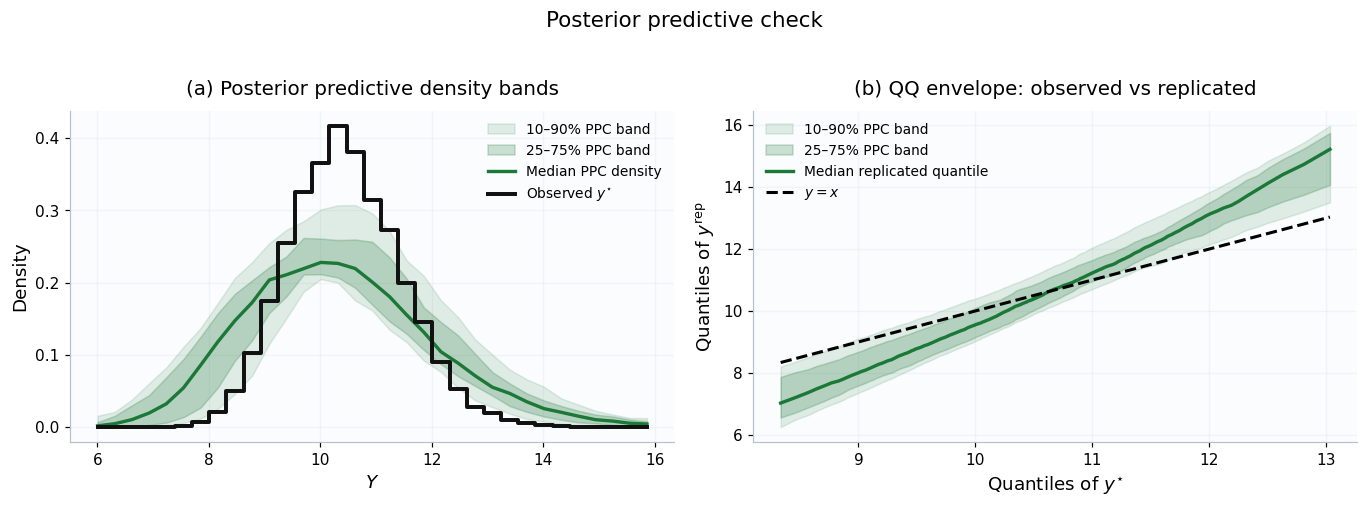

Observed std = 1.01
Mean replicated std = 1.65


In [19]:
key_base = random.PRNGKey(2029)
key_idx, key_sim = random.split(key_base)
n_rep = 50
q_grid = np.linspace(0.01, 0.99, 180)
obs_q = np.quantile(y_obs, q_grid)

# Draw replicated datasets once, then summarize them with bands.
idx = np.array(random.choice(key_idx, len(accepted), shape=(n_rep,), replace=True))
keys_ppc = random.split(key_sim, n_rep)
y_reps = np.array([
    simulate_sum_lognormal(k, accepted[i, 0], accepted[i, 1], L, n)
    for k, i in zip(keys_ppc, idx)
])

bins = np.linspace(
    min(np.quantile(y_obs, 0.001), np.quantile(y_reps, 0.001)),
    max(np.quantile(y_obs, 0.995), np.quantile(y_reps, 0.995)),
    34,
)
centers, obs_density = hist_density(y_obs, bins)
rep_densities = np.array([hist_density(y_rep, bins)[1] for y_rep in y_reps])
rep_q = np.array([np.quantile(y_rep, q_grid) for y_rep in y_reps])

fig, axes = plt.subplots(1, 2, figsize=(12.6, 4.5))

# (a) Histogram envelope
q10, q25, q50, q75, q90 = np.quantile(rep_densities, [0.10, 0.25, 0.50, 0.75, 0.90], axis=0)
axes[0].fill_between(centers, q10, q90, color=C_GREEN, alpha=0.12, label="10–90% PPC band")
axes[0].fill_between(centers, q25, q75, color=C_GREEN, alpha=0.22, label="25–75% PPC band")
axes[0].plot(centers, q50, color=C_GREEN, lw=2.2, label="Median PPC density")
axes[0].step(centers, obs_density, where="mid", color="#111111", lw=2.6, label=r"Observed $y^{\star}$")
axes[0].set_xlabel(r"$Y$")
axes[0].set_ylabel("Density")
axes[0].set_title("(a) Posterior predictive density bands")
axes[0].legend(fontsize=9, loc="upper right")

# (b) QQ envelope
qq10, qq25, qq50, qq75, qq90 = np.quantile(rep_q, [0.10, 0.25, 0.50, 0.75, 0.90], axis=0)
axes[1].fill_between(obs_q, qq10, qq90, color=C_GREEN, alpha=0.12, label="10–90% PPC band")
axes[1].fill_between(obs_q, qq25, qq75, color=C_GREEN, alpha=0.22, label="25–75% PPC band")
axes[1].plot(obs_q, qq50, color=C_GREEN, lw=2.2, label="Median replicated quantile")
lims = [obs_q.min(), obs_q.max()]
axes[1].plot(lims, lims, "k--", lw=2, label="$y=x$")
axes[1].set_xlabel(r"Quantiles of $y^{\star}$")
axes[1].set_ylabel(r"Quantiles of $y^{\rm rep}$")
axes[1].set_title("(b) QQ envelope: observed vs replicated")
axes[1].legend(fontsize=9, loc="upper left")

plt.suptitle("Posterior predictive check", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print(f"Observed std = {y_obs.std():.2f}")
print(f"Mean replicated std = {y_reps.std(axis=1).mean():.2f}")

The posterior predictive check points in the same direction as the parameter estimates. The replicated datasets are centered in roughly the right place, but they are visibly more spread out than the observed sample. The QQ plot tells the same story: the lower replicated quantiles fall below the diagonal and the upper ones rise above it, which is the usual sign of overdispersion.

That fits the parameter results. The ABC posterior is still placing too much mass on larger values of $\sigma^2$, so posterior-predictive samples come out too variable. In the current run, the observed sample has standard deviation about $1.01$, while the replicated samples average around $1.6$.

So the PPC is useful here because it confirms the same issue from a different angle. The model is not completely off, but under the current ABC posterior it is still too diffuse.

## Summary of Question 1

For Project 3, Question 1, Reject-ABC is a sensible way to attack this problem. The likelihood is intractable, but simulation is easy, and the MEWE-style averaged 1-Wasserstein score gives us a clean way to compare observed and simulated data.

The first lesson is about $\varepsilon$: smaller tolerances help, but they cost a lot more. In this notebook, the 1% level is a reasonable working choice because it improves the posterior a lot compared with 10% without becoming too expensive. It does not remove ABC bias completely, though.

The second lesson is that the prior on $\log\sigma^2$ matters much more than the prior on $\mu$. With the default $t = 1$, the prior is still centered far above the true value $\sigma^2 = 0.09$, and that keeps the posterior for $\sigma^2$ too high. Widening that prior helps because it puts more mass in the region supported by the data.

Repeated runs show that Monte Carlo noise is small, and the posterior predictive check tells the same story as the parameter estimates: under the default setup, the posterior is still too spread out. So the right conclusion is not that Reject-ABC fails, and also not that it solves everything. It works, it gives sensible information, and it shows clearly where the remaining difficulty comes from: finite $\varepsilon$ and prior sensitivity.

That makes Question 2 a natural next step, since MCMC-ABC should let us work with smaller effective tolerances more efficiently.